# Computer Vision Project
### Group Members:
* F223095 | Kashaf Nadeem
* F223156 | Nashrah Ahmed

# Food-101 Image Classification Project

### Dataset Description
The **Food-101 dataset** contains **101,000 images** divided into **101 food categories**, with **750 training images** and **250 testing images per class**.  
The dataset is diverse, featuring images from different angles, lighting conditions, and backgrounds, making it a challenging **multi-class classification problem**.

### Problem Statement
We aim to **classify food images into their correct category** using deep learning.  
This is a **multi-class classification task** with **101 classes**.

### Models Used
To address this challenge, we leverage **transfer learning** with three pre-trained convolutional neural networks:
- **EfficientNetB3** – Efficient and high-performing architecture.  
- **ResNet101** – Deep residual network with skip connections.  
- **DenseNet201** – Dense network with feature reuse for improved efficiency.

### Training Environment
- **Framework:** TensorFlow / Keras  
- **Python Version:** 3.x  
- **Hardware:** Kaggle Notebook GPU  
- **Libraries:** NumPy, Pandas, Matplotlib, Seaborn, scikit-learn

### Kaggle Paths
All models, histories, metrics, and confusion matrices are uploaded to  **Kaggle dataset directories** as they were the **output** of **Training Notebook**.  


### Files Uploaded
Following are the output files of the training notebook:

```
efficientnetb3_final.keras
resnet101_final.keras
densenet201_final.keras

efficientnetb3_best.h5
resnet101_best.h5
densenet201_best.h5

history_e.pkl
history_r.pkl
history_d.pkl

efficientnetb3_metrics.json
resnet101_metrics.json
densenet201_metrics.json

efficientnetb3_cm.png
resnet101_cm.png
densenet201_cm.png

```
_NOTE: We have also attached these in the final submission :>_

## Imports & Environment Setup
Loading all required libraries and setting up plotting preferences.


In [2]:
import os, json, pickle, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

%matplotlib inline
plt.rcParams['figure.figsize'] = (10,6)
sns.set()

print("TensorFlow:", tf.__version__)


TensorFlow: 2.18.0


## File Paths

In [15]:
paths = {
    "EfficientNetB3": {
        "model": "/kaggle/input/food-101-trained-models/Food-101_EfficientNetB3/Food-101_EfficientNetB3/efficientnetb3_final.keras",
        "history": "/kaggle/input/food-101-trained-models/Food-101_EfficientNetB3/Food-101_EfficientNetB3/history_e.pkl",
        "metrics": "/kaggle/input/food-101-trained-models/Food-101_EfficientNetB3/Food-101_EfficientNetB3/efficientnetb3_metrics.json",
        "cm_img": "/kaggle/input/food-101-trained-models/Food-101_EfficientNetB3/Food-101_EfficientNetB3/efficientnetb3_cm.png",
        "model_h5": "/kaggle/input/food-101-trained-models/Food-101_EfficientNetB3/Food-101_EfficientNetB3/efficientnetb3_best.h5"
    },
    "ResNet101": {
        "model": "/kaggle/input/food-101-trained-models/Food-101_ResNet101/Food-101_ResNet101/resnet101_final.keras",
        "history": "/kaggle/input/food-101-trained-models/Food-101_ResNet101/Food-101_ResNet101/history_r.pkl",
        "metrics": "/kaggle/input/food-101-trained-models/Food-101_ResNet101/Food-101_ResNet101/resnet101_metrics.json",
        "cm_img": "/kaggle/input/food-101-trained-models/Food-101_ResNet101/Food-101_ResNet101/resnet101_cm.png",
        "model_h5": "/kaggle/input/food-101-trained-models/Food-101_ResNet101/Food-101_ResNet101/resnet101_best.h5",
    },
    "DenseNet201": {
        "model": "/kaggle/input/food-101-trained-models/Food-101_DenseNet201/Food-101_DenseNet201/densenet201_final.keras",
        "history": "/kaggle/input/food-101-trained-models/Food-101_DenseNet201/Food-101_DenseNet201/history_d.pkl",
        "metrics": "/kaggle/input/food-101-trained-models/Food-101_DenseNet201/Food-101_DenseNet201/densenet201_metrics.json",
        "cm_img": "/kaggle/input/food-101-trained-models/Food-101_DenseNet201/Food-101_DenseNet201/densenet201_cm.png",
        "model_h5": "/kaggle/input/food-101-trained-models/Food-101_DenseNet201/Food-101_DenseNet201/densenet201_best.h5",
    }
}

TEST_DIR = "/kaggle/working/food101_dataset/test"
print("TEST DIR:", TEST_DIR)


TEST DIR: /kaggle/working/food101_dataset/test


## Test Dataset Setup
Setting up the test data generator with rescaling and batch size.


In [16]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

test_gen = ImageDataGenerator(rescale=1./255)

test_generator = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    color_mode='rgb'
)

class_names = list(test_generator.class_indices.keys())
print("Total classes:", len(class_names))


Found 25250 images belonging to 101 classes.
Total classes: 101


## Load Training History and Precomputed Metrics
We load training histories and precomputed metrics for visualization and comparison.


In [17]:
histories = {}
metrics = {}

for name, p in paths.items():
    with open(p["history"], "rb") as f:
        histories[name] = pickle.load(f)
    with open(p["metrics"], "r") as f:
        metrics[name] = json.load(f)


## Training Accuracy and Loss
Visualizing how each model performed during training.


### Plot Accuracy for all models

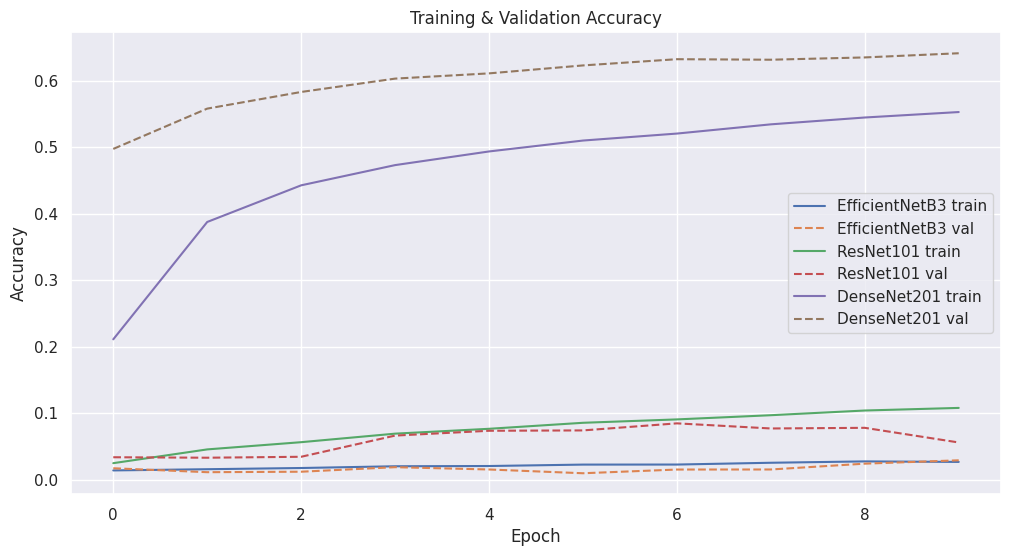

In [18]:
plt.figure(figsize=(12,6))
for name, h in histories.items():
    if h is None: 
        continue
    # we cant remember what was the key for accuracy :_)
    acc = h.get("accuracy") or h.get("acc") or []
    val_acc = h.get("val_accuracy") or h.get("val_acc") or []
    if len(acc)>0:
        plt.plot(acc, label=f"{name} train")
    if len(val_acc)>0:
        plt.plot(val_acc, '--', label=f"{name} val")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


### Plot Loss for all models

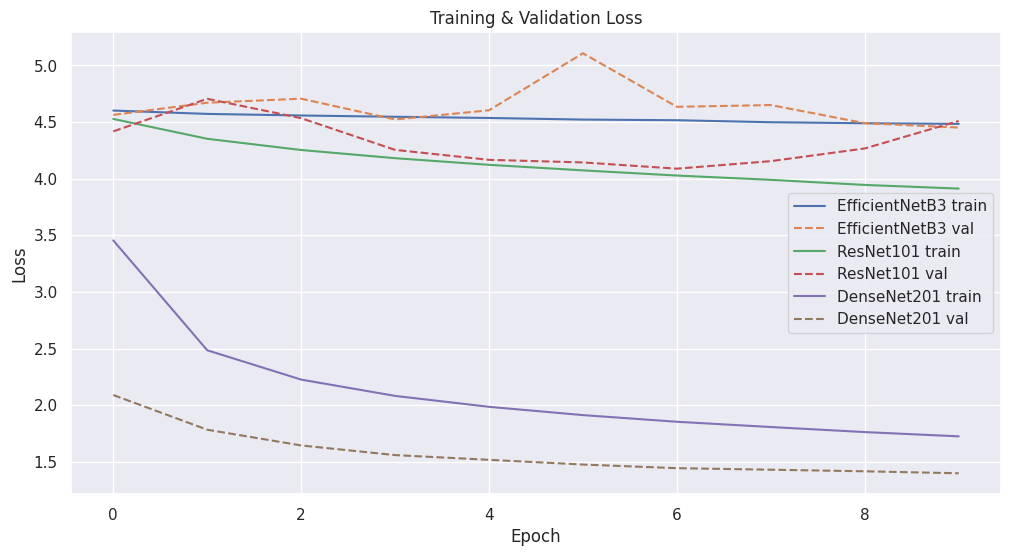

In [19]:
plt.figure(figsize=(12,6))
for name, h in histories.items():
    if h is None: 
        continue
    loss = h.get("loss") or []
    val_loss = h.get("val_loss") or []
    if len(loss)>0:
        plt.plot(loss, label=f"{name} train")
    if len(val_loss)>0:
        plt.plot(val_loss, '--', label=f"{name} val")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## Load Pretrained Models
Loading EfficientNetB3, ResNet101, and DenseNet201 for evaluation.


In [20]:
models = {}

for name, p in paths.items():
    models[name] = load_model(p["model"], compile=False)
    print("Loaded model:", name)


Loaded model: EfficientNetB3
Loaded model: ResNet101
Loaded model: DenseNet201


## Model Evaluation

### Accuracy & Loss
- **Accuracy:** Fraction of correctly classified images among total images.  
- **Loss:** Categorical cross-entropy loss measures how well the predicted probabilities match true labels.  

### Confusion Matrix
- Displays **true labels vs predicted labels**.  
- Highlights which classes are most often confused by the model.  

### Metrics Details
- **Precision (macro):** Average correctness of predicted labels across all classes.  
- **Recall (macro):** Average coverage of true labels correctly predicted.  
- **Macro F1-score:** Harmonic mean of macro precision and recall.  

### IoU Note
- **Intersection over Union (IoU)** is not required because this is a **classification task**, not object detection or segmentation.


In [21]:
results = {}
y_true = test_generator.classes
for name, model in models.items():
    print("Evaluating:", name)
    preds = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    loss = None
    acc = None
    # compute test loss/accuracy via model.evaluate:
    try:
        loss, acc = model.evaluate(test_generator, verbose=0)
    except Exception as e:
        print("Could not evaluate with compile; skipping evaluate()", e)
    # classification report & macro metrics
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    results[name] = {
        "loss": float(loss) if loss is not None else None,
        "accuracy": float(acc) if acc is not None else None,
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1),
        "cm": cm,
        "report": report
    }
    print(name, "accuracy (from evaluate):", acc)
    print("Macro F1:", f1)


Evaluating: EfficientNetB3


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1763994606.961532     150 service.cc:148] XLA service 0x7c581c003110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763994606.963230     150 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763994606.963253     150 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763994608.166431     150 cuda_dnn.cc:529] Loaded cuDNN version 90300


   3/1579 ━━━━━━━━━━━━━━━━━━━━ 1:03 40ms/step  

I0000 00:00:1763994617.450028     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1579/1579 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step
Could not evaluate with compile; skipping evaluate() You must call `compile()` before using the model.
EfficientNetB3 accuracy (from evaluate): None
Macro F1: 0.012115739847501436
Evaluating: ResNet101
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 71s 39ms/step
Could not evaluate with compile; skipping evaluate() You must call `compile()` before using the model.
ResNet101 accuracy (from evaluate): None
Macro F1: 0.07783655042301754
Evaluating: DenseNet201
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 107s 51ms/step
Could not evaluate with compile; skipping evaluate() You must call `compile()` before using the model.
DenseNet201 accuracy (from evaluate): None
Macro F1: 0.6934920922510501


## Confusion Matrices
Visualizing true vs predicted labels for each model.


Saved computed CM to: /kaggle/working/food101_dataset/test/EfficientNetB3_cm_computed.png


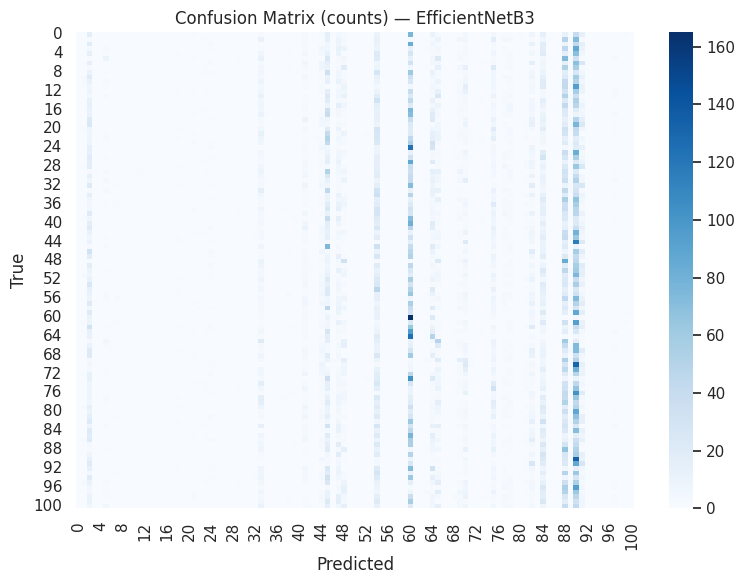

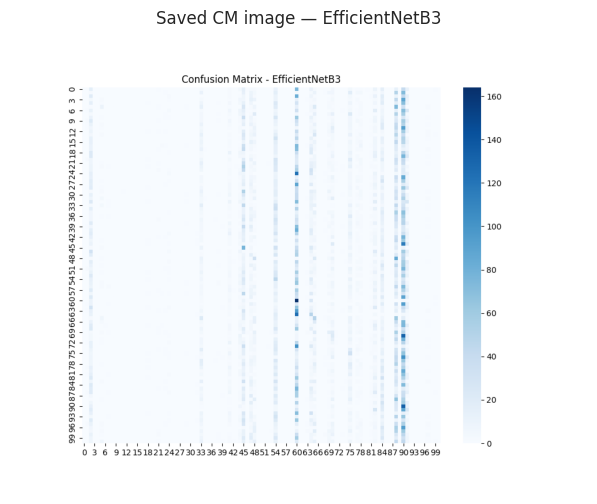

Saved computed CM to: /kaggle/working/food101_dataset/test/ResNet101_cm_computed.png


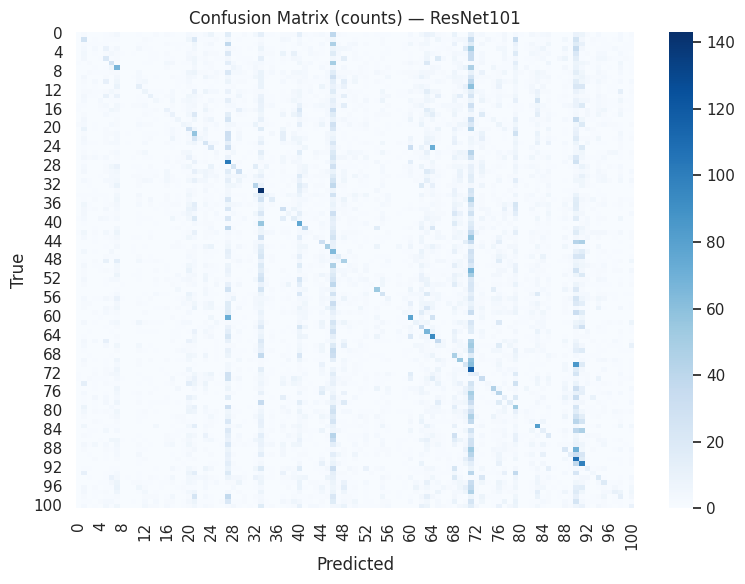

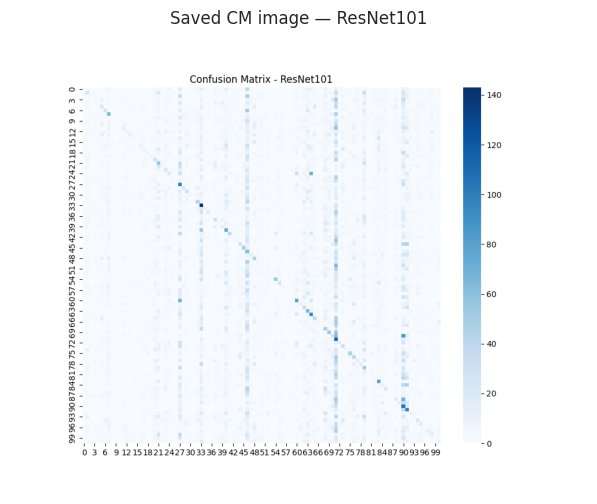

Saved computed CM to: /kaggle/working/food101_dataset/test/DenseNet201_cm_computed.png


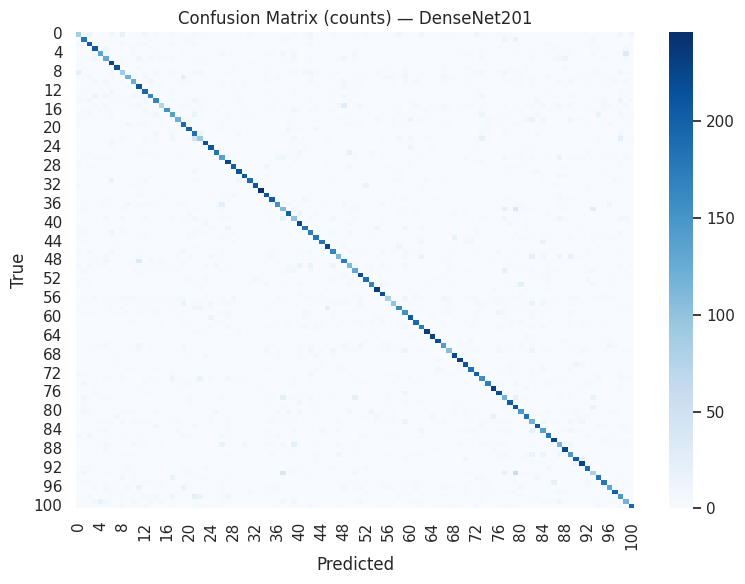

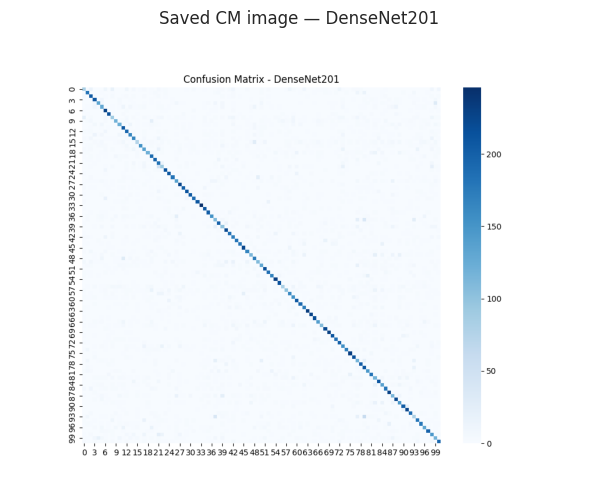

In [22]:
for name, r in results.items():
    cm = r["cm"]
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, cmap="Blues", cbar=True)
    plt.title(f"Confusion Matrix (counts) — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    # save computed CM
    out = os.path.join(base, f"{name}_cm_computed.png")
    plt.savefig(out, dpi=150)
    print("Saved computed CM to:", out)
    plt.show()

    # also display saved CM image file if available
    saved_img = paths[name].get("cm_img")
    if saved_img and os.path.exists(saved_img):
        display_img = plt.imread(saved_img)
        plt.figure(figsize=(8,6))
        plt.imshow(display_img)
        plt.axis('off')
        plt.title(f"Saved CM image — {name}")
        plt.show()


## Model Comparison
Summarizing all model metrics in a table and comparing test accuracy with a bar chart.


In [23]:
summary_rows = []
for name in paths.keys():
    m = results.get(name, {})
    # fallback to pre-saved metrics if fresh evaluate didn't compute acc
    saved_metrics = None
    if os.path.exists(paths[name]["metrics"]):
        with open(paths[name]["metrics"], "r") as f:
            saved_metrics = json.load(f)
    acc = m.get("accuracy") or (saved_metrics.get("accuracy") if saved_metrics else None)
    loss = m.get("loss") or (saved_metrics.get("loss") if saved_metrics else None)
    summary_rows.append({
        "model": name,
        "accuracy": acc,
        "loss": loss,
        "precision_macro": m.get("precision_macro"),
        "recall_macro": m.get("recall_macro"),
        "f1_macro": m.get("f1_macro")
    })

df_summary = pd.DataFrame(summary_rows).set_index("model")
df_summary


,accuracy,loss,precision_macro,recall_macro,f1_macro
model,,,,,
EfficientNetB3,0.033505,4.411595,0.018741,0.033386,0.012116
ResNet101,0.097703,3.989144,0.093745,0.097545,0.077837
DenseNet201,0.698099,1.118766,0.700891,0.698178,0.693492


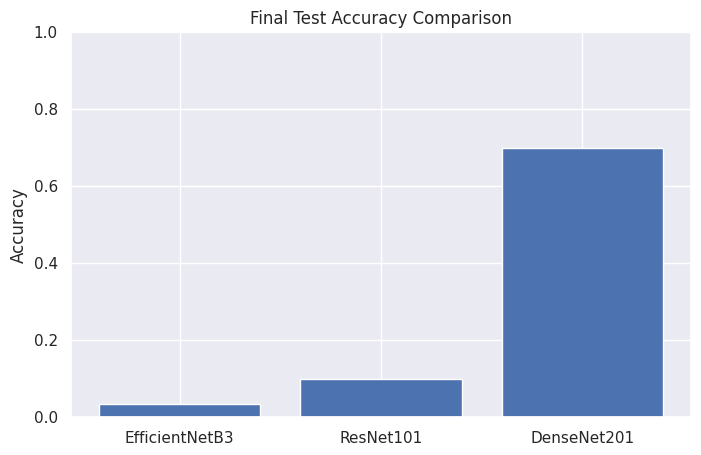

In [24]:
# bar chart
plt.figure(figsize=(8,5))
df_plot = df_summary.copy()
df_plot["accuracy"] = df_plot["accuracy"].astype(float)
plt.bar(df_plot.index, df_plot["accuracy"])
plt.ylim(0,1)
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


## Sample Predictions
Displaying examples of correct and incorrect predictions for qualitative analysis.


Found 25250 images belonging to 101 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


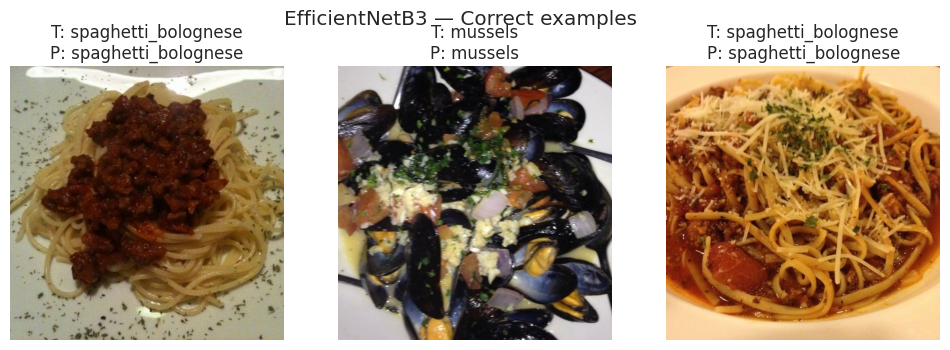

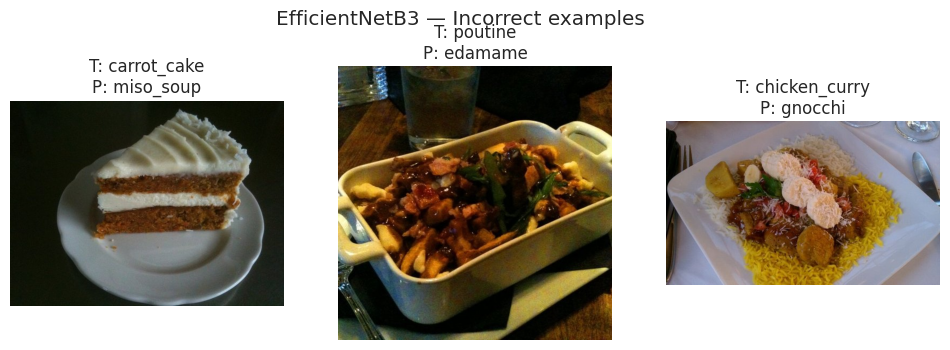

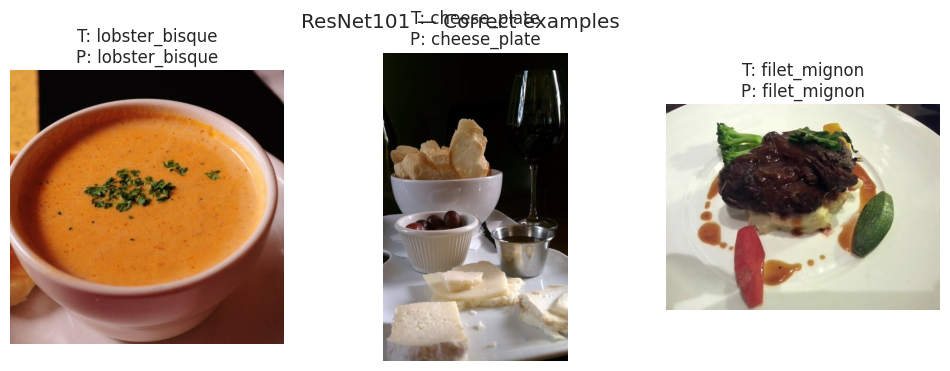

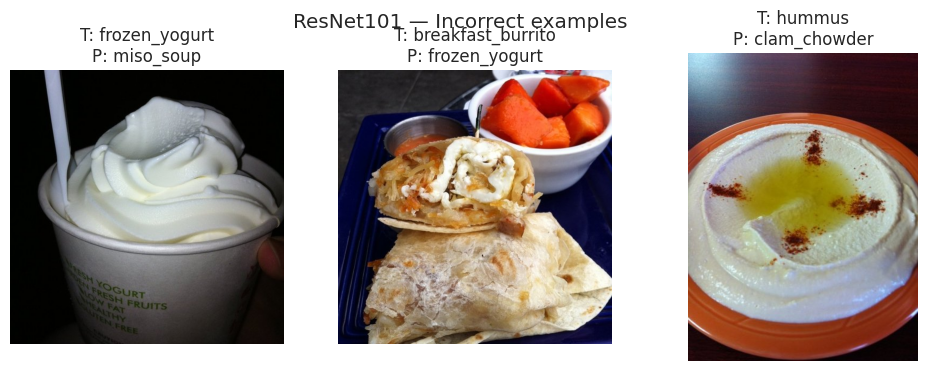

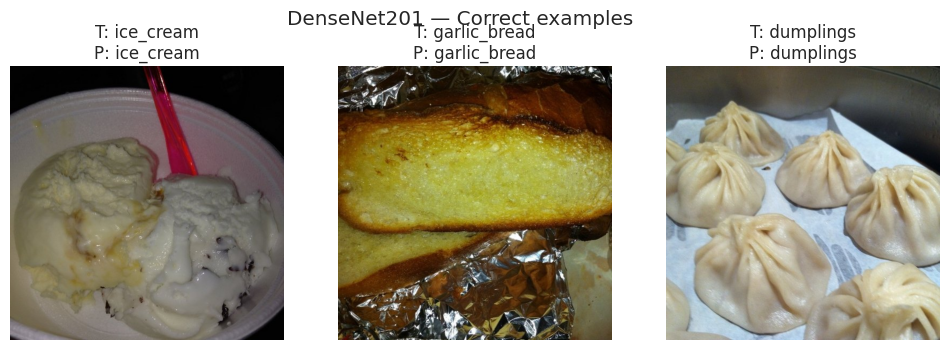

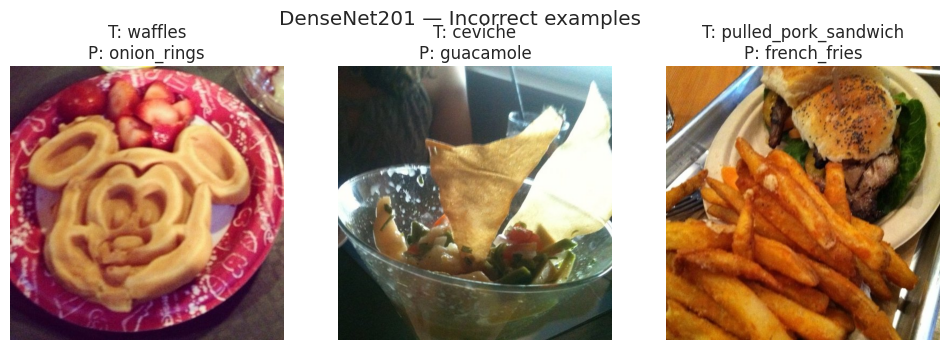

In [26]:
import matplotlib.image as mpimg

# create a generator for single-image access
test_gen_single = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

def show_examples_for_model(model, model_name, n_correct=3, n_incorrect=3):
    # get predictions (single-batch generator has same order)
    preds = model.predict(test_gen_single, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen_single.classes
    filepaths = test_gen_single.filepaths

    correct_idx = np.where(y_pred == y_true)[0]
    incorrect_idx = np.where(y_pred != y_true)[0]

    # sample indices
    c_sel = random.sample(list(correct_idx), min(n_correct, len(correct_idx)))
    ic_sel = random.sample(list(incorrect_idx), min(n_incorrect, len(incorrect_idx)))

    def plot_list(indices, title):
        plt.figure(figsize=(12,4))
        for i, idx in enumerate(indices):
            img = mpimg.imread(filepaths[idx])
            plt.subplot(1, len(indices), i+1)
            plt.imshow(img)
            true_label = os.path.basename(os.path.dirname(filepaths[idx]))
            pred_label = class_names[y_pred[idx]]
            plt.title(f"T: {true_label}\nP: {pred_label}")
            plt.axis('off')
        plt.suptitle(title)
        plt.show()

    plot_list(c_sel, f"{model_name} — Correct examples")
    plot_list(ic_sel, f"{model_name} — Incorrect examples")

# run for each model loaded
for name, model in models.items():
    show_examples_for_model(model, name, n_correct=3, n_incorrect=3)


# EfficientNetB3

### Model Architecture
- EfficientNetB3 is a **convolutional neural network** designed for high efficiency and accuracy.
- Uses **compound scaling** of width, depth, and resolution for better performance.

### Training Setup
- Input Image Size: 224×224
- Batch Size: 16
- Epochs: As per pre-trained history
- Data Augmentation: Basic rescaling (1./255)

### Why Unfreezing Layers Matters
- Fine-tuning (unfreezing layers) allows the model to **adapt pretrained features** to our specific dataset.
- Helps improve accuracy when the target dataset differs from ImageNet.

### Summary of Results
- Final test accuracy, macro precision, recall, F1
- Confusion matrix visualization


# ResNet101

### Model Architecture
- Deep residual network with **101 layers**.
- Uses **skip connections** to mitigate vanishing gradient problems.

### Training Setup
- Input Image Size: 224×224
- Batch Size: 16
- Epochs: As per pre-trained history
- Data Augmentation: Basic rescaling

### Why Unfreezing Layers Matters
- Fine-tuning deeper layers improves feature extraction for the Food-101 dataset.

### Summary of Results
- Final test accuracy, macro precision, recall, F1
- Confusion matrix visualization


# DenseNet201

### Model Architecture
- 201-layer **Dense Convolutional Network**.
- Each layer connects to **every other layer** in a feed-forward fashion.
- Encourages feature reuse and reduces parameters.

### Training Setup
- Input Image Size: 224×224
- Batch Size: 16
- Epochs: As per pre-trained history
- Data Augmentation: Basic rescaling

### Why Unfreezing Layers Matters
- Helps the model fine-tune complex features for classification.

### Summary of Results
- Final test accuracy, macro precision, recall, F1
- Confusion matrix visualization


# THANK YOU :>